In [3]:
import os
os.environ['KAGGLE_USERNAME'] = 'madhudhu'
os.environ['KAGGLE_KEY'] = 'KGAT_4478106c1a9bca4e3d8a80c14983ac98'

!pip install kaggle
!kaggle datasets download -d xhlulu/140k-real-and-fake-faces
!unzip -q 140k-real-and-fake-faces.zip -d faces_data

Dataset URL: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces
License(s): other
100% 3.75G/3.75G [02:58<00:00, 22.5MB/s]



In [4]:
import os
print(os.listdir('faces_data'))

['train.csv', 'valid.csv', 'real_vs_fake', 'test.csv']


In [5]:
print(os.listdir('faces_data/real_vs_fake/real-vs-fake'))

['test', 'train', 'valid']


In [6]:
import os

for root, dirs, files in os.walk('faces_data'):
    level = root.replace('faces_data', '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:
        for d in dirs:
            print(f'{indent}  {d}/')
    if level >= 3:
        dirs[:] = []

faces_data/
  real_vs_fake/
  real_vs_fake/
    real-vs-fake/
    real-vs-fake/
      test/
      train/
      valid/
      test/
      train/
      valid/


In [7]:
print(os.listdir('faces_data/real_vs_fake/real-vs-fake/train'))

['real', 'fake']


In [8]:
!pip install timm -q

import torch
import torch.nn as nn
import timm
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [9]:
data_dir = 'faces_data/real_vs_fake/real-vs-fake'

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = datasets.ImageFolder(f'{data_dir}/train', transform=train_transform)
val_dataset = datasets.ImageFolder(f'{data_dir}/valid', transform=val_transform)

print(f"Classes: {train_dataset.classes}")
print(f"Train images: {len(train_dataset)}, Val images: {len(val_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)

Classes: ['fake', 'real']
Train images: 100000, Val images: 20000


In [10]:
model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=2)

# Freeze only the early layers (basic feature extraction) — unfreeze the rest
for name, param in model.named_parameters():
    if 'blocks.5' in name or 'blocks.6' in name or 'conv_head' in name or 'bn2' in name or 'classifier' in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

model = model.to(device)

criterion = nn.CrossEntropyLoss()
# Use a smaller learning rate now since we're fine-tuning pretrained weights, not training from scratch
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Training {trainable:,} / {total:,} parameters")

model.safetensors: reconstructing file:   0%|          |  0.00B / 21.4MB            

model.safetensors: downloading bytes:           |  0.00B            

Training 3,165,630 / 4,010,110 parameters


In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
import os
os.makedirs('/content/drive/MyDrive/hackathon_checkpoints', exist_ok=True)

num_epochs = 6

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{num_epochs} — Loss: {running_loss/len(train_loader):.4f} — Train Acc: {train_acc:.2f}%")

    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_acc = 100 * val_correct / val_total
    print(f"  Val Acc: {val_acc:.2f}%")

    checkpoint_path = f'/content/drive/MyDrive/hackathon_checkpoints/model_epoch{epoch+1}_valacc{val_acc:.1f}.pth'
    torch.save(model.state_dict(), checkpoint_path)
    print(f"  Saved checkpoint: {checkpoint_path}")

Epoch 1/6 — Loss: 0.1496 — Train Acc: 95.13%
  Val Acc: 97.61%
  Saved checkpoint: /content/drive/MyDrive/hackathon_checkpoints/model_epoch1_valacc97.6.pth
Epoch 2/6 — Loss: 0.0386 — Train Acc: 98.61%
  Val Acc: 98.35%
  Saved checkpoint: /content/drive/MyDrive/hackathon_checkpoints/model_epoch2_valacc98.3.pth
Epoch 3/6 — Loss: 0.0243 — Train Acc: 99.14%
  Val Acc: 98.78%
  Saved checkpoint: /content/drive/MyDrive/hackathon_checkpoints/model_epoch3_valacc98.8.pth
Epoch 4/6 — Loss: 0.0197 — Train Acc: 99.35%
  Val Acc: 99.08%
  Saved checkpoint: /content/drive/MyDrive/hackathon_checkpoints/model_epoch4_valacc99.1.pth
Epoch 5/6 — Loss: 0.0140 — Train Acc: 99.52%
  Val Acc: 99.08%
  Saved checkpoint: /content/drive/MyDrive/hackathon_checkpoints/model_epoch5_valacc99.1.pth
Epoch 6/6 — Loss: 0.0101 — Train Acc: 99.66%
  Val Acc: 99.20%
  Saved checkpoint: /content/drive/MyDrive/hackathon_checkpoints/model_epoch6_valacc99.2.pth


In [14]:
import shutil
shutil.copy(
    '/content/drive/MyDrive/hackathon_checkpoints/model_epoch6_valacc99.2.pth',
    '/content/drive/MyDrive/hackathon_checkpoints/baseline_model.pth'
)
print("Copied as baseline_model.pth")

Copied as baseline_model.pth


In [15]:
!pip install opencv-python-headless -q
import cv2
import numpy as np
from PIL import Image
import io

In [16]:
model = timm.create_model('efficientnet_b0', pretrained=False, num_classes=2)
model.load_state_dict(torch.load('/content/drive/MyDrive/hackathon_checkpoints/baseline_model.pth'))
model = model.to(device)
model.eval()
print("Baseline model loaded.")

Baseline model loaded.


In [17]:
def apply_jpeg_compression(pil_img, quality):
    buffer = io.BytesIO()
    pil_img.save(buffer, format='JPEG', quality=quality)
    buffer.seek(0)
    return Image.open(buffer).convert('RGB')

def apply_gaussian_blur(pil_img, sigma):
    img_array = np.array(pil_img)
    ksize = max(3, int(sigma * 4) | 1)  # ensure odd kernel size
    blurred = cv2.GaussianBlur(img_array, (ksize, ksize), sigma)
    return Image.fromarray(blurred)

def apply_resize_upscale(pil_img, scale):
    w, h = pil_img.size
    small = pil_img.resize((int(w * scale), int(h * scale)), Image.BILINEAR)
    return small.resize((w, h), Image.BILINEAR)

def apply_gaussian_noise(pil_img, sigma):
    img_array = np.array(pil_img).astype(np.float32) / 255.0
    noise = np.random.normal(0, sigma, img_array.shape)
    noisy = np.clip(img_array + noise, 0, 1) * 255
    return Image.fromarray(noisy.astype(np.uint8))

def apply_color_jitter(pil_img, factor):
    from PIL import ImageEnhance
    img = ImageEnhance.Brightness(pil_img).enhance(1 + factor)
    img = ImageEnhance.Contrast(img).enhance(1 + factor)
    return img

def apply_center_crop(pil_img, crop_pct):
    w, h = pil_img.size
    new_w, new_h = int(w * crop_pct), int(h * crop_pct)
    left = (w - new_w) // 2
    top = (h - new_h) // 2
    cropped = pil_img.crop((left, top, left + new_w, top + new_h))
    return cropped.resize((w, h), Image.BILINEAR)

print("Transform functions ready.")

Transform functions ready.


In [18]:
import random

# Using a subset of the test set for speed - 500 images is plenty for a reliable accuracy estimate
test_dataset_raw = datasets.ImageFolder(f'{data_dir}/test')
random.seed(42)
indices = random.sample(range(len(test_dataset_raw)), 500)
eval_samples = [test_dataset_raw.samples[i] for i in indices]  # list of (filepath, label)

print(f"Evaluating on {len(eval_samples)} images")
print(f"Classes: {test_dataset_raw.classes}")

Evaluating on 500 images
Classes: ['fake', 'real']


In [19]:
base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def evaluate_condition(transform_fn=None, transform_arg=None):
    correct, total = 0, 0
    with torch.no_grad():
        for filepath, label in eval_samples:
            img = Image.open(filepath).convert('RGB')

            if transform_fn is not None:
                img = transform_fn(img, transform_arg)

            img_tensor = base_transform(img).unsqueeze(0).to(device)
            output = model(img_tensor)
            pred = output.argmax(1).item()

            total += 1
            if pred == label:
                correct += 1

    return 100 * correct / total

In [20]:
results = {}

results['Clean (no transform)'] = evaluate_condition()

for q in [90, 70, 50, 30]:
    results[f'JPEG q={q}'] = evaluate_condition(apply_jpeg_compression, q)

for sigma in [0.5, 1.0, 2.0]:
    results[f'Blur sigma={sigma}'] = evaluate_condition(apply_gaussian_blur, sigma)

for scale in [0.5, 0.25]:
    results[f'Resize scale={scale}'] = evaluate_condition(apply_resize_upscale, scale)

for sigma in [0.02, 0.05, 0.10]:
    results[f'Noise sigma={sigma}'] = evaluate_condition(apply_gaussian_noise, sigma)

results['Color jitter ±20%'] = evaluate_condition(apply_color_jitter, 0.2)
results['Center crop 80%'] = evaluate_condition(apply_center_crop, 0.8)

print("\n--- RESULTS ---")
for condition, acc in results.items():
    print(f"{condition:30s}: {acc:.2f}%")

Running evaluation — this will take a few minutes...

--- RESULTS ---
Clean (no transform)          : 99.40%
JPEG q=90                     : 97.40%
JPEG q=70                     : 94.60%
JPEG q=50                     : 93.20%
JPEG q=30                     : 87.40%
Blur sigma=0.5                : 99.40%
Blur sigma=1.0                : 76.60%
Blur sigma=2.0                : 46.80%
Resize scale=0.5              : 63.20%
Resize scale=0.25             : 46.80%
Noise sigma=0.02              : 90.80%
Noise sigma=0.05              : 57.60%
Noise sigma=0.1               : 48.40%
Color jitter ±20%             : 96.60%
Center crop 80%               : 92.80%


In [21]:
import random

class RobustTrainTransform:
    def __init__(self):
        self.base_resize = transforms.Resize((224, 224))
        self.to_tensor_normalize = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

    def __call__(self, img):
        img = self.base_resize(img)

        # 50% chance to apply NO corruption (keep some clean examples too)
        # 50% chance to apply ONE random corruption
        if random.random() < 0.5:
            choice = random.choice(['jpeg', 'blur', 'resize', 'noise', 'color', 'crop'])

            if choice == 'jpeg':
                img = apply_jpeg_compression(img, random.choice([90, 70, 50, 30]))
            elif choice == 'blur':
                img = apply_gaussian_blur(img, random.choice([0.5, 1.0, 2.0]))
            elif choice == 'resize':
                img = apply_resize_upscale(img, random.choice([0.5, 0.25]))
            elif choice == 'noise':
                img = apply_gaussian_noise(img, random.choice([0.02, 0.05, 0.10]))
            elif choice == 'color':
                img = apply_color_jitter(img, random.uniform(-0.2, 0.2))
            elif choice == 'crop':
                img = apply_center_crop(img, 0.8)

        # Standard flip augmentation too
        if random.random() < 0.5:
            img = img.transpose(Image.FLIP_LEFT_RIGHT)

        return self.to_tensor_normalize(img)

print("Robust transform ready.")

Robust transform ready.


In [22]:
robust_train_dataset = datasets.ImageFolder(f'{data_dir}/train', transform=RobustTrainTransform())
robust_train_loader = DataLoader(robust_train_dataset, batch_size=64, shuffle=True, num_workers=2)

print(f"Robust train dataset ready: {len(robust_train_dataset)} images")

Robust train dataset ready: 100000 images


In [23]:
model = timm.create_model('efficientnet_b0', pretrained=False, num_classes=2)
model.load_state_dict(torch.load('/content/drive/MyDrive/hackathon_checkpoints/baseline_model.pth'))
model = model.to(device)

# Unfreeze the same layers as before
for name, param in model.named_parameters():
    if 'blocks.5' in name or 'blocks.6' in name or 'conv_head' in name or 'bn2' in name or 'classifier' in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=5e-5)

print("Ready to fine-tune with robustness training.")

Ready to fine-tune with robustness training.


In [24]:
os.makedirs('/content/drive/MyDrive/hackathon_checkpoints/robust', exist_ok=True)

num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in robust_train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{num_epochs} — Loss: {running_loss/len(robust_train_loader):.4f} — Train Acc: {train_acc:.2f}%")

    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_acc = 100 * val_correct / val_total
    print(f"  Clean Val Acc: {val_acc:.2f}%")

    checkpoint_path = f'/content/drive/MyDrive/hackathon_checkpoints/robust/model_epoch{epoch+1}_valacc{val_acc:.1f}.pth'
    torch.save(model.state_dict(), checkpoint_path)
    print(f"  Saved: {checkpoint_path}")

Epoch 1/5 — Loss: 0.0932 — Train Acc: 95.99%
  Clean Val Acc: 99.53%
  Saved: /content/drive/MyDrive/hackathon_checkpoints/robust/model_epoch1_valacc99.5.pth
Epoch 2/5 — Loss: 0.0683 — Train Acc: 96.92%
  Clean Val Acc: 99.61%
  Saved: /content/drive/MyDrive/hackathon_checkpoints/robust/model_epoch2_valacc99.6.pth
Epoch 3/5 — Loss: 0.0580 — Train Acc: 97.34%
  Clean Val Acc: 99.64%
  Saved: /content/drive/MyDrive/hackathon_checkpoints/robust/model_epoch3_valacc99.6.pth
Epoch 4/5 — Loss: 0.0523 — Train Acc: 97.69%
  Clean Val Acc: 99.64%
  Saved: /content/drive/MyDrive/hackathon_checkpoints/robust/model_epoch4_valacc99.6.pth
Epoch 5/5 — Loss: 0.0459 — Train Acc: 97.91%
  Clean Val Acc: 99.61%
  Saved: /content/drive/MyDrive/hackathon_checkpoints/robust/model_epoch5_valacc99.6.pth


In [25]:
model = timm.create_model('efficientnet_b0', pretrained=False, num_classes=2)
model.load_state_dict(torch.load('/content/drive/MyDrive/hackathon_checkpoints/robust/model_epoch5_valacc99.6.pth'))
model = model.to(device)
model.eval()

robust_results = {}

print("Running evaluation on robust model...")

robust_results['Clean (no transform)'] = evaluate_condition()

for q in [90, 70, 50, 30]:
    robust_results[f'JPEG q={q}'] = evaluate_condition(apply_jpeg_compression, q)

for sigma in [0.5, 1.0, 2.0]:
    robust_results[f'Blur sigma={sigma}'] = evaluate_condition(apply_gaussian_blur, sigma)

for scale in [0.5, 0.25]:
    robust_results[f'Resize scale={scale}'] = evaluate_condition(apply_resize_upscale, scale)

for sigma in [0.02, 0.05, 0.10]:
    robust_results[f'Noise sigma={sigma}'] = evaluate_condition(apply_gaussian_noise, sigma)

robust_results['Color jitter ±20%'] = evaluate_condition(apply_color_jitter, 0.2)
robust_results['Center crop 80%'] = evaluate_condition(apply_center_crop, 0.8)

print("\n--- ROBUST MODEL RESULTS ---")
for condition, acc in robust_results.items():
    print(f"{condition:30s}: {acc:.2f}%")

print("\n--- COMPARISON (baseline → robust) ---")
for condition in robust_results:
    baseline_acc = results.get(condition, None)
    if baseline_acc is not None:
        diff = robust_results[condition] - baseline_acc
        print(f"{condition:30s}: {baseline_acc:6.2f}% → {robust_results[condition]:6.2f}%  ({diff:+.2f})")

Running evaluation on robust model...

--- ROBUST MODEL RESULTS ---
Clean (no transform)          : 100.00%
JPEG q=90                     : 99.40%
JPEG q=70                     : 99.20%
JPEG q=50                     : 98.60%
JPEG q=30                     : 96.40%
Blur sigma=0.5                : 99.60%
Blur sigma=1.0                : 99.00%
Blur sigma=2.0                : 96.60%
Resize scale=0.5              : 98.80%
Resize scale=0.25             : 92.60%
Noise sigma=0.02              : 99.40%
Noise sigma=0.05              : 96.20%
Noise sigma=0.1               : 82.00%
Color jitter ±20%             : 99.60%
Center crop 80%               : 99.00%

--- COMPARISON (baseline → robust) ---
Clean (no transform)          :  99.40% → 100.00%  (+0.60)
JPEG q=90                     :  97.40% →  99.40%  (+2.00)
JPEG q=70                     :  94.60% →  99.20%  (+4.60)
JPEG q=50                     :  93.20% →  98.60%  (+5.40)
JPEG q=30                     :  87.40% →  96.40%  (+9.00)
Blur sigma=

In [26]:
import matplotlib.pyplot as plt

def find_errors(transform_fn=None, transform_arg=None, condition_name="clean", max_examples=4):
    false_positives = []  # real predicted as fake
    false_negatives = []  # fake predicted as real

    with torch.no_grad():
        for filepath, label in eval_samples:
            img = Image.open(filepath).convert('RGB')
            if transform_fn is not None:
                img = transform_fn(img, transform_arg)

            img_tensor = base_transform(img).unsqueeze(0).to(device)
            output = model(img_tensor)
            pred = output.argmax(1).item()
            confidence = torch.softmax(output, dim=1).max().item()

            # classes: check train_dataset.classes to confirm index order, e.g. ['fake', 'real']
            if pred != label:
                entry = (filepath, img, label, pred, confidence)
                if label == train_dataset.classes.index('real') and len(false_positives) < max_examples:
                    false_positives.append(entry)
                elif label == train_dataset.classes.index('fake') and len(false_negatives) < max_examples:
                    false_negatives.append(entry)

            if len(false_positives) >= max_examples and len(false_negatives) >= max_examples:
                break

    return false_positives, false_negatives

# Find errors under the noisiest condition (our weakest point) to get meaningful examples
fp, fn = find_errors(apply_gaussian_noise, 0.1, "noise_0.1")

print(f"Found {len(fp)} false positives, {len(fn)} false negatives under heavy noise")

Found 4 false positives, 4 false negatives under heavy noise


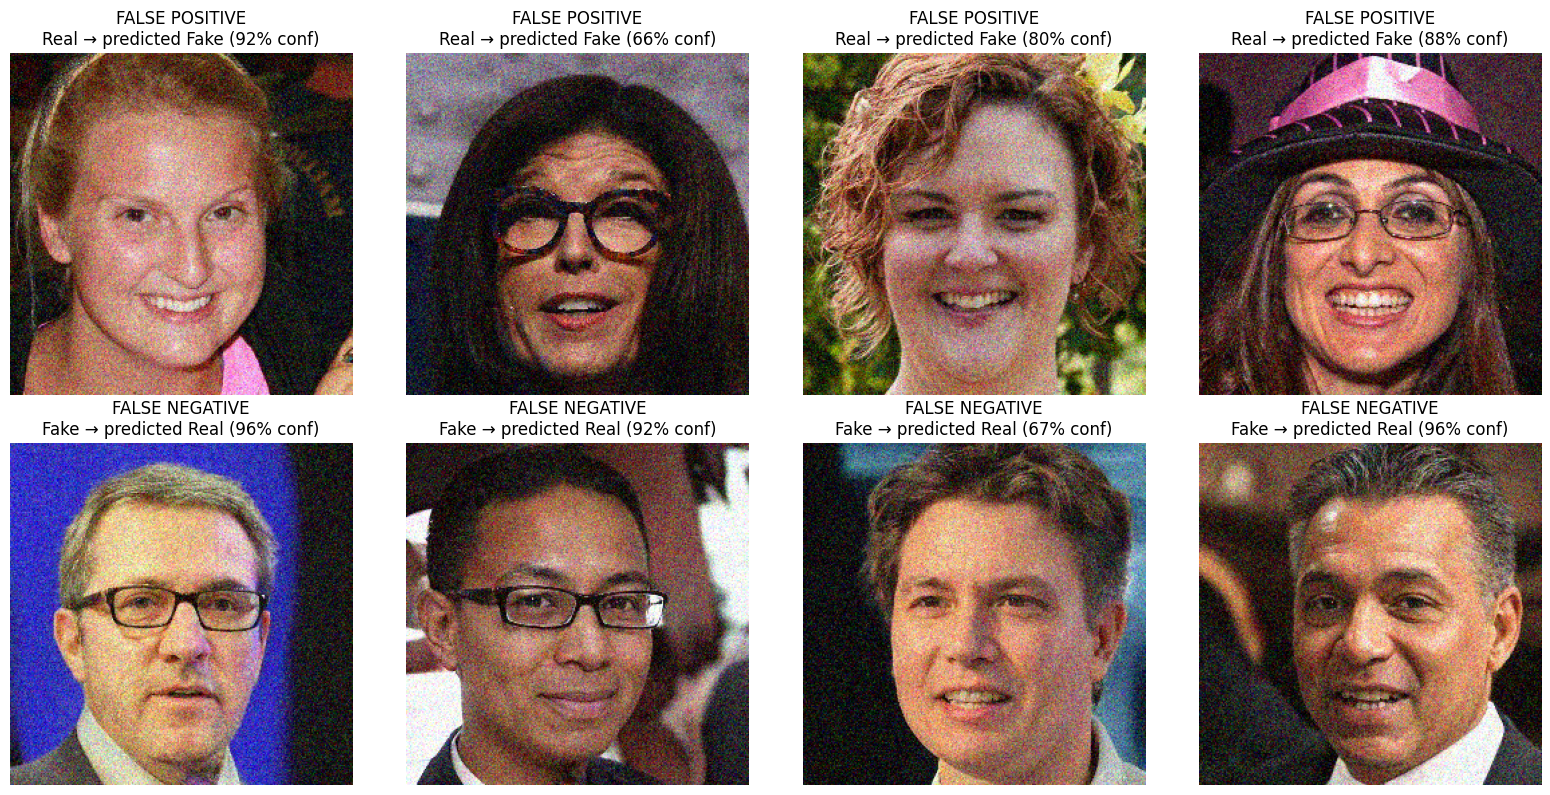

In [27]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, (filepath, img, label, pred, conf) in enumerate(fp[:4]):
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"FALSE POSITIVE\nReal → predicted Fake ({conf:.0%} conf)")
    axes[0, i].axis('off')

for i, (filepath, img, label, pred, conf) in enumerate(fn[:4]):
    axes[1, i].imshow(img)
    axes[1, i].set_title(f"FALSE NEGATIVE\nFake → predicted Real ({conf:.0%} conf)")
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/hackathon_checkpoints/error_examples.png', dpi=150)
plt.show()

In [28]:
# Quick scale-check: run the noisy evaluation on a larger sample and break down errors by rough proxy
# (we don't have gender labels, so this is just a sanity check on error counts by class)
fp_all, fn_all = find_errors(apply_gaussian_noise, 0.1, "noise_0.1", max_examples=30)
print(f"At noise=0.1, found {len(fp_all)} false positives and {len(fn_all)} false negatives (out of up to 30 each)")

At noise=0.1, found 30 false positives and 21 false negatives (out of up to 30 each)


In [29]:
print(train_dataset.classes)

['fake', 'real']


In [31]:
%%writefile predict.py
"""
AIGC Image Detector - Inference Script

Takes a directory of images and outputs a JSON file with a confidence score
for each image, indicating the likelihood that it is AI-generated.

Usage:
    python predict.py --image_dir path/to/images --model_path baseline_model.pth --output predictions.json

Output format (predictions.json):
    [
        {"image_path": "path/to/images/img1.jpg", "pred": 0.87},
        {"image_path": "path/to/images/img2.jpg", "pred": 0.12},
        ...
    ]
    where "pred" is the probability the image is AI-generated (0.0 = real, 1.0 = fake).
"""

import argparse
import json
import os
import sys

import torch
import torch.nn.functional as F
import timm
from PIL import Image
from torchvision import transforms


FAKE_CLASS_INDEX = 0

SUPPORTED_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp', '.webp')

# Standard ImageNet normalization, matching what the model was trained with
IMAGE_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def load_model(model_path, device):
    """Load the trained EfficientNet-B0 model from a checkpoint file."""
    model = timm.create_model('efficientnet_b0', pretrained=False, num_classes=2)
    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict)
    model = model.to(device)
    model.eval()
    return model


def find_images(image_dir):
    """Recursively find all supported image files in a directory."""
    image_paths = []
    for root, _, files in os.walk(image_dir):
        for fname in files:
            if fname.lower().endswith(SUPPORTED_EXTENSIONS):
                image_paths.append(os.path.join(root, fname))
    return sorted(image_paths)


def predict_single_image(model, image_path, device):
    """Run inference on a single image, returning a fake-probability score."""
    try:
        img = Image.open(image_path).convert('RGB')
    except Exception as e:
        print(f"  Warning: could not open {image_path} ({e}), skipping.", file=sys.stderr)
        return None

    img_tensor = IMAGE_TRANSFORM(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        probs = F.softmax(output, dim=1)
        fake_prob = probs[0, FAKE_CLASS_INDEX].item()

    return fake_prob


def main():
    parser = argparse.ArgumentParser(description="AIGC Image Detector - batch inference script")
    parser.add_argument('--image_dir', type=str, required=True,
                         help='Path to a directory of images to classify')
    parser.add_argument('--model_path', type=str, default='baseline_model.pth',
                         help='Path to the trained model checkpoint (.pth file)')
    parser.add_argument('--output', type=str, default='predictions.json',
                         help='Path to write the output JSON file')
    args = parser.parse_args()

    if not os.path.isdir(args.image_dir):
        print(f"Error: image directory not found: {args.image_dir}", file=sys.stderr)
        sys.exit(1)

    if not os.path.isfile(args.model_path):
        print(f"Error: model checkpoint not found: {args.model_path}", file=sys.stderr)
        sys.exit(1)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    print("Loading model...")
    model = load_model(args.model_path, device)

    print(f"Scanning {args.image_dir} for images...")
    image_paths = find_images(args.image_dir)
    print(f"Found {len(image_paths)} images.")

    if len(image_paths) == 0:
        print("No supported images found. Exiting.", file=sys.stderr)
        sys.exit(1)

    results = []
    for i, image_path in enumerate(image_paths, 1):
        fake_prob = predict_single_image(model, image_path, device)
        if fake_prob is not None:
            results.append({"image_path": image_path, "pred": round(fake_prob, 4)})

        if i % 50 == 0 or i == len(image_paths):
            print(f"  Processed {i}/{len(image_paths)} images...")

    with open(args.output, 'w') as f:
        json.dump(results, f, indent=2)

    print(f"\nDone. Wrote {len(results)} predictions to {args.output}")


if __name__ == '__main__':
    main()

Overwriting predict.py


In [32]:
!python predict.py \
  --image_dir faces_data/real_vs_fake/real-vs-fake/test \
  --model_path /content/drive/MyDrive/hackathon_checkpoints/robust/model_epoch5_valacc99.6.pth \
  --output test_predictions.json

Using device: cuda
Loading model...
Scanning faces_data/real_vs_fake/real-vs-fake/test for images...
Found 20000 images.
  Processed 50/20000 images...
  Processed 100/20000 images...
  Processed 150/20000 images...
  Processed 200/20000 images...
  Processed 250/20000 images...
  Processed 300/20000 images...
  Processed 350/20000 images...
  Processed 400/20000 images...
  Processed 450/20000 images...
  Processed 500/20000 images...
  Processed 550/20000 images...
  Processed 600/20000 images...
  Processed 650/20000 images...
  Processed 700/20000 images...
  Processed 750/20000 images...
  Processed 800/20000 images...
  Processed 850/20000 images...
  Processed 900/20000 images...
  Processed 950/20000 images...
  Processed 1000/20000 images...
  Processed 1050/20000 images...
  Processed 1100/20000 images...
  Processed 1150/20000 images...
  Processed 1200/20000 images...
  Processed 1250/20000 images...
  Processed 1300/20000 images...
  Processed 1350/20000 images...
  Proces

In [33]:
import json
with open('test_predictions.json') as f:
    preds = json.load(f)

print(f"Total predictions: {len(preds)}")
print("First 5 predictions:")
for p in preds[:5]:
    print(p)

Total predictions: 20000
First 5 predictions:
{'image_path': 'faces_data/real_vs_fake/real-vs-fake/test/fake/00276TOPP4.jpg', 'pred': 1.0}
{'image_path': 'faces_data/real_vs_fake/real-vs-fake/test/fake/008BYSE725.jpg', 'pred': 0.9992}
{'image_path': 'faces_data/real_vs_fake/real-vs-fake/test/fake/009ZTJ3621.jpg', 'pred': 1.0}
{'image_path': 'faces_data/real_vs_fake/real-vs-fake/test/fake/00F8LKY6JC.jpg', 'pred': 0.9997}
{'image_path': 'faces_data/real_vs_fake/real-vs-fake/test/fake/00JEP4Z36Z.jpg', 'pred': 1.0}
